# The PolInSAR Course - December 2, 2024 
# SAR Interferometry (InSAR) 
# Part 2: The InSAR Coherence & Height Inversion

* TanDEM-X acquisition over Mondah forest (Gabon)
* Path: '/data/insar/'
* SLCs: master_HH_Mondah_S_2015_11_11_cut.npy, slave_HH_Mondah_S_2015_11_11_cut.npy
* Flat-earth: flat_earth_Mondah_S_2015_11_11_cut.npy
* Full-waveform Lidar (LVIS) RH100: RH100_Mondah_S_2015_11_11_cut.npy

Objective:
- Calculate InSAR coherence with a 20 m resolution, estimate forest height using the provided formulas, and validate the result against lidar.

Tips:
- Compensate system decorrelation 0.97
- Invalid points in the RH100 are set to -9999

In [1]:
# --- Download exercise data & import reader function
from pysarpro import io, data
from pysarpro.io import rrat

data.download_all(directory="/projects", pattern=r'^data/insar')

# --- Import useful libraries, functions and modules
import sys
sys.path.append('/projects/src/')
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter

%matplotlib widget

Matplotlib created a temporary cache directory at /tmp/matplotlib-kaiunqri because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
def calculate_covariance(im1, im2, looksr, looksa) : 
    
    corr = uniform_filter(np.real(im1*np.conj(im2)), [looksa,looksr]) + 1j* \
                uniform_filter(np.imag(im1*np.conj(im2)), [looksa,looksr])
    
    return corr

**Input parameters**

In [3]:
# path 2 images
path = 'data/insar/'

# Input TDX pixel spacing, in meters
spacrg = 1.36411
spacaz = 1.86817

# TDX vertical wavenumber, in rad / meters
kz = 0.06092195

# Output range resolution, in meters
resrg = 20.
resaz = 20.

# System decorrelation
coh_sys = 0.97

**Step 1: Open images, and visualize**

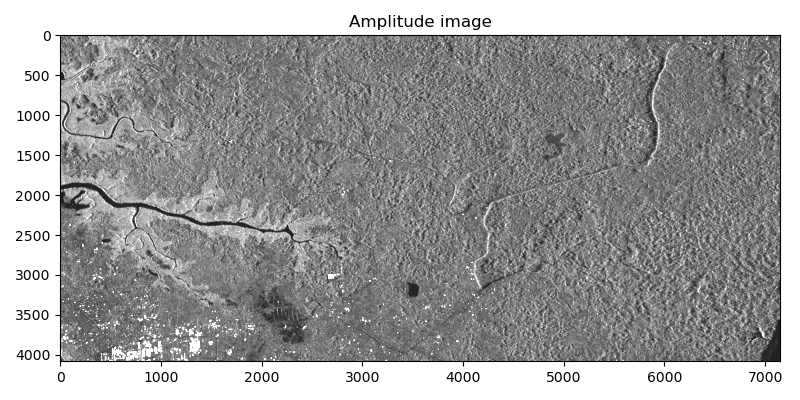

In [4]:
# --- open images
im1 = np.load(path + 'master_HH_Mondah_S_2015_11_11_cut.npy')
im2 = np.load(path + 'slave_HH_Mondah_S_2015_11_11_cut.npy')

# --- compute the amplitude
amp1 = np.sqrt(np.abs(calculate_covariance(im1, im1, 7, 7)))

# --- display
plt.figure(figsize=(8,4))
plt.imshow(amp1, vmin=0, vmax=2*np.mean(amp1), aspect='auto', cmap='gray')
plt.title('Amplitude image')
plt.tight_layout()

**Step 2 : Compensate flat-earth**

In [5]:
# --- open the flat-earth phase term
fe = np.load(path + 'flat_earth_Mondah_S_2015_11_11_cut.npy')

In [11]:
# --- compensate
im2_fe = im2 * np.exp(1j*fe)

**Step 3: Calculate coherence**

In [8]:
# --- calculate the number of looks
looksr = int(resrg/spacrg)
if looksr%2 == 0: looksr += 1
looksa = int(resaz/spacaz)
if looksa%2 == 0: looksa += 1

In [12]:
# ---calculate coherence
interf = calculate_covariance(im1, im2_fe, looksr, looksa)
amp1 = np.sqrt(np.abs(calculate_covariance(im1, im1, looksr, looksa)))
amp2 = np.sqrt(np.abs(calculate_covariance(im2_fe, im2_fe, looksr, looksa)))
coherence = interf / (amp1 * amp2)

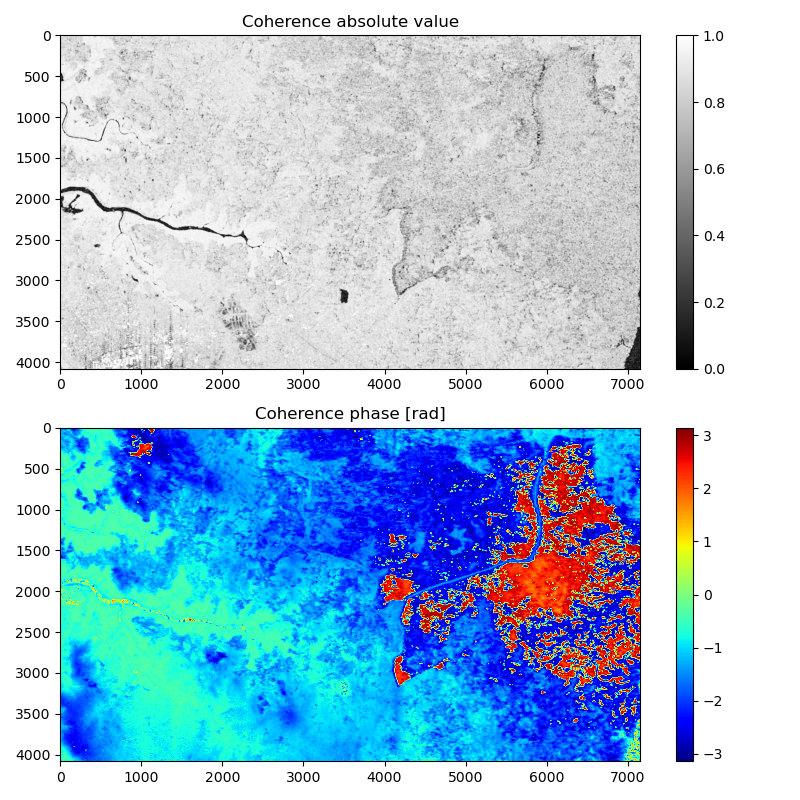

In [13]:
# --- display
plt.figure(figsize=(8,8))
plt.subplot(211)
plt.imshow(np.abs(coherence), vmin=0, vmax=1, aspect='auto', cmap='gray')
plt.colorbar()
plt.title('Coherence absolute value')
plt.subplot(212)
plt.imshow(np.angle(coherence), vmin=-np.pi, vmax=np.pi, aspect='auto', cmap='jet')
plt.colorbar()
plt.title('Coherence phase [rad]')
plt.tight_layout()

**Step 4 : Invert for forest height (closed-form)**

In [ ]:
# ...

In [ ]:
# ...

# ...

**Step 5 : Validation**

In [ ]:
# ...

# ...

In [ ]:
# ...